In [1]:
# Daily share of unavailable nights
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

LST = "../data/silver/nyc/listings.parquet"
CAL = "../data/silver/nyc/calendar.parquet"

daily = duckdb.sql(f"""
    WITH active AS (
        SELECT
            listing_id,
            CASE WHEN quote_nights < 28 THEN 'short stay'
                 ELSE 'monthly stay' END AS stay_type
        FROM read_parquet('{LST}')
        WHERE price IS NOT NULL
    )
    SELECT
        c.calendar_date,
        a.stay_type,
        COUNT(*) AS listings,
        AVG(CASE WHEN c.is_available = FALSE THEN 100.0
                 WHEN c.is_available = TRUE  THEN 0.0 END) AS pct_unavailable
    FROM read_parquet('{CAL}') c
    JOIN active a ON c.listing_id = a.listing_id
    WHERE c.calendar_date BETWEEN DATE '2026-06-23' AND DATE '2027-06-13'
    GROUP BY 1, 2
    ORDER BY 1
""").df()

print(daily.head())
print("Rows:", len(daily))

  calendar_date     stay_type  listings  pct_unavailable
0    2026-06-23  monthly stay     16522        60.949038
1    2026-06-23    short stay      4993        53.935510
2    2026-06-24    short stay      4993        57.119968
3    2026-06-24  monthly stay     16522        60.604043
4    2026-06-25    short stay      4993        62.066894
Rows: 712


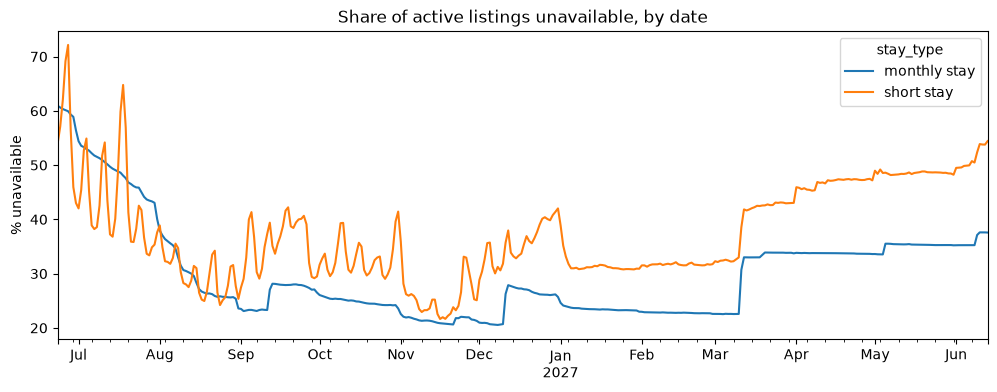

In [2]:
# Plot demand over the year
chart = daily.pivot(index="calendar_date", columns="stay_type",
                    values="pct_unavailable")

ax = chart.plot(figsize=(12, 4))
ax.set_title("Share of active listings unavailable, by date")
ax.set_ylabel("% unavailable")
ax.set_xlabel("")
plt.show()

In [3]:
# Does unavailability depend on how far ahead the date is?
ahead = duckdb.sql(f"""
    WITH active AS (
        SELECT listing_id,
               CASE WHEN quote_nights < 28 THEN 'short stay'
                    ELSE 'monthly stay' END AS stay_type
        FROM read_parquet('{LST}')
        WHERE price IS NOT NULL
    )
    SELECT
        FLOOR(c.days_from_start / 30) * 30 AS days_ahead_from,
        a.stay_type,
        ROUND(AVG(CASE WHEN c.is_available = FALSE THEN 100.0
                       WHEN c.is_available = TRUE  THEN 0.0 END), 1)
                                           AS pct_unavailable
    FROM read_parquet('{CAL}') c
    JOIN active a ON c.listing_id = a.listing_id
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

print(ahead.pivot(index="days_ahead_from", columns="stay_type",
                  values="pct_unavailable"))

stay_type        monthly stay  short stay
days_ahead_from                          
0.0                      57.6        53.4
30.0                     40.9        37.5
60.0                     25.2        30.5
90.0                     26.9        35.4
120.0                    23.5        30.3
150.0                    21.1        27.6
180.0                    25.8        35.9
210.0                    23.2        31.2
240.0                    22.7        32.1
270.0                    33.9        43.8
300.0                    34.0        47.9
330.0                    35.3        49.3
360.0                    38.2        56.1


In [4]:
# Weekday pattern for short stays
weekday = duckdb.sql(f"""
    WITH active AS (
        SELECT listing_id
        FROM read_parquet('{LST}')
        WHERE price IS NOT NULL AND quote_nights < 28
    )
    SELECT
        ISODOW(c.calendar_date)   AS day_number,   -- 1 = Monday ... 7 = Sunday
        DAYNAME(c.calendar_date)  AS day_name,
        ROUND(AVG(CASE WHEN c.is_available = FALSE THEN 100.0
                       WHEN c.is_available = TRUE  THEN 0.0 END), 1)
                                  AS pct_unavailable
    FROM read_parquet('{CAL}') c
    JOIN active a ON c.listing_id = a.listing_id
    WHERE c.days_from_start BETWEEN 1 AND 90
    GROUP BY 1, 2
    ORDER BY 1
""").df()

print(weekday)

   day_number   day_name  pct_unavailable
0           1     Monday             35.3
1           2    Tuesday             36.4
2           3  Wednesday             37.0
3           4   Thursday             40.0
4           5     Friday             45.4
5           6   Saturday             46.7
6           7     Sunday             39.6


In [5]:
# Do quoted prices differ by month?
by_month = duckdb.sql(f"""
    SELECT
        MONTH(quote_checkin_date)            AS month_number,
        MONTHNAME(quote_checkin_date)        AS month,
        COUNT(*)                             AS listings,
        ROUND(MEDIAN(price), 0)              AS median_price,
        ROUND(MEDIAN(pre_discount_nightly_price), 0)
                                             AS median_pre_discount
    FROM read_parquet('{LST}')
    WHERE price IS NOT NULL
      AND room_type = 'Entire home/apt'
      AND quote_nights < 28
    GROUP BY 1, 2
    ORDER BY 1
""").df()

print(by_month)

   month_number      month  listings  median_price  median_pre_discount
0             1    January        26         275.0                275.0
1             3      March         1         953.0                953.0
2             5        May         2         382.0                382.0
3             6       June      1235         406.0                408.0
4             7       July       264         422.0                425.0
5             8     August        49         338.0                347.0
6             9  September         5         421.0                421.0
7            10    October         2         310.0                310.0
8            11   November         5         271.0                271.0
